# Stock Price Prediction with LSTM
time series forecasting using recurrent neural networks
idea: use last 60 days to predict the next day's price

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
tf.random.set_seed(42)

price range: $83.37 - $183.57


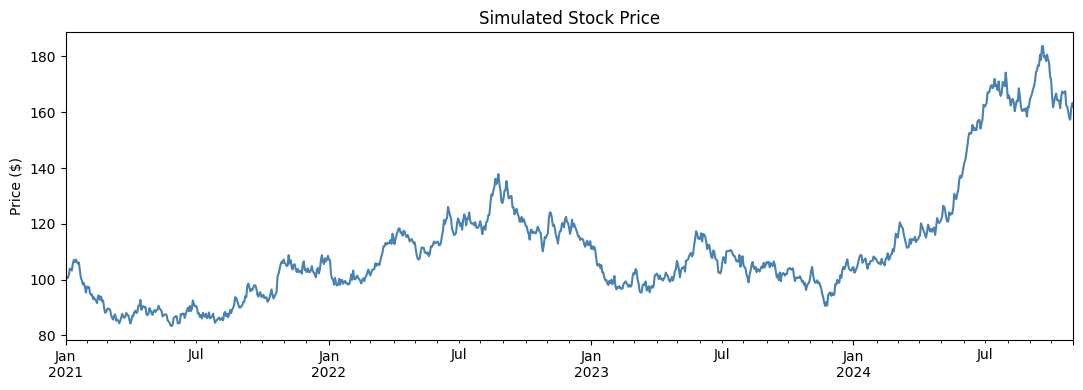

In [2]:
# simulate stock prices using geometric brownian motion (like real stocks)
def simulate_stock(n=1000, start=100, drift=0.0002, vol=0.015):
    returns = np.random.normal(drift, vol, n)
    prices = [start]
    for r in returns:
        prices.append(prices[-1] * np.exp(r))
    dates = pd.date_range('2021-01-01', periods=n, freq='B')
    return pd.Series(prices[:n], index=dates)

prices = simulate_stock()
print(f"price range: ${prices.min():.2f} - ${prices.max():.2f}")

plt.figure(figsize=(13,4))
prices.plot(color='steelblue')
plt.title('Simulated Stock Price')
plt.ylabel('Price ($)')
plt.show()

In [3]:
lookback = 60  # use past 60 days

# scale to 0-1
scaler = MinMaxScaler()
scaled = scaler.fit_transform(prices.values.reshape(-1, 1))

# create sequences
X, y = [], []
for i in range(lookback, len(scaled)):
    X.append(scaled[i-lookback:i, 0])
    y.append(scaled[i, 0])

X, y = np.array(X), np.array(y)

# train/test split - keep it chronological!
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# reshape for lstm: (samples, timesteps, features)
X_train = X_train.reshape(-1, lookback, 1)
X_test = X_test.reshape(-1, lookback, 1)

print(f"train: {X_train.shape}, test: {X_test.shape}")

train: (752, 60, 1), test: (188, 60, 1)


In [4]:
model = keras.Sequential([
    layers.LSTM(64, return_sequences=True, input_shape=(lookback, 1)),
    layers.Dropout(0.2),
    layers.LSTM(32),
    layers.Dropout(0.2),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)  # predict next price
])

model.compile(optimizer=keras.optimizers.Adam(0.001), loss='mse', metrics=['mae'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 60, 64)              │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 60, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)
]

history = model.fit(X_train, y_train,
                    batch_size=32,
                    epochs=50,
                    validation_split=0.1,
                    callbacks=callbacks,
                    verbose=1)

Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 70ms/step - loss: 0.0143 - mae: 0.0909 - val_loss: 0.0025 - val_mae: 0.0437 - learning_rate: 0.0010
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 0.0042 - mae: 0.0513 - val_loss: 0.0015 - val_mae: 0.0324 - learning_rate: 0.0010
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 0.0028 - mae: 0.0404 - val_loss: 0.0013 - val_mae: 0.0279 - learning_rate: 0.0010
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 0.0022 - mae: 0.0351 - val_loss: 0.0011 - val_mae: 0.0249 - learning_rate: 0.0010
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0020 - mae: 0.0338 - val_loss: 9.7049e-04 - val_mae: 0.0237 - learning_rate: 0.0010
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 0.0019 - mae: 0.0329 - val_loss: 9.5443e-04 - val_mae: 0.0235 - learning_rate: 0.0010
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.0019 - mae: 0.0326 - val_loss: 0.0010 - val_mae: 0.0241 - learning_rate: 0.0010
Epoch

In [6]:
# evaluate on test set
y_pred = model.predict(X_test, verbose=0)

# inverse transform back to real prices
actual = scaler.inverse_transform(y_test.reshape(-1,1)).flatten()
predicted = scaler.inverse_transform(y_pred).flatten()

rmse = np.sqrt(mean_squared_error(actual, predicted))
mae = mean_absolute_error(actual, predicted)
mape = np.mean(np.abs((actual - predicted) / actual)) * 100

print(f"RMSE: ${rmse:.4f}")
print(f"MAE:  ${mae:.4f}")
print(f"MAPE: {mape:.2f}%")

RMSE: $7.5461
MAE:  $6.2703
MAPE: 4.13%


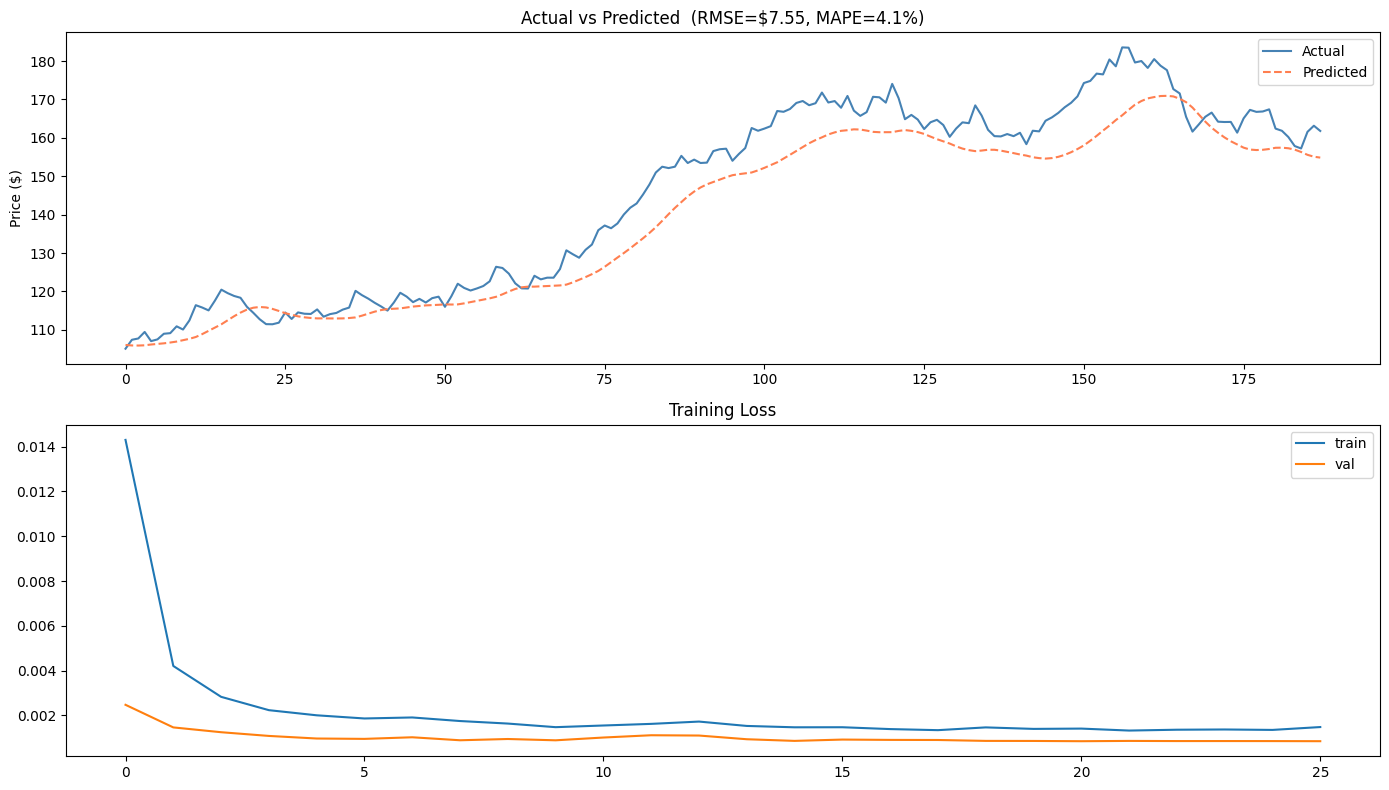

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(actual, label='Actual', color='steelblue')
axes[0].plot(predicted, label='Predicted', color='coral', linestyle='--')
axes[0].set_title(f'Actual vs Predicted  (RMSE=${rmse:.2f}, MAPE={mape:.1f}%)')
axes[0].set_ylabel('Price ($)')
axes[0].legend()

axes[1].plot(history.history['loss'], label='train')
axes[1].plot(history.history['val_loss'], label='val')
axes[1].set_title('Training Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

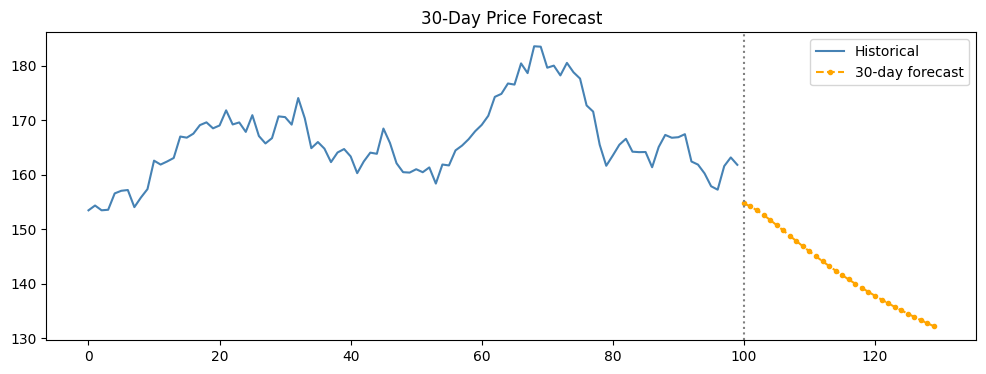

In [8]:
# forecast next 30 days
last_seq = scaled[-lookback:, 0].tolist()
future = []

for _ in range(30):
    inp = np.array(last_seq[-lookback:]).reshape(1, lookback, 1)
    pred = model.predict(inp, verbose=0)[0, 0]
    future.append(pred)
    last_seq.append(pred)

future_prices = scaler.inverse_transform(np.array(future).reshape(-1,1)).flatten()

plt.figure(figsize=(12, 4))
plt.plot(range(100), prices.values[-100:], label='Historical', color='steelblue')
plt.plot(range(100, 130), future_prices, label='30-day forecast',
         color='orange', linestyle='--', marker='o', markersize=3)
plt.axvline(100, color='gray', linestyle=':')
plt.title('30-Day Price Forecast')
plt.legend()
plt.show()